## P25_37d — multi-parameter sweep exports

Streamlined version of P25_37b. Sweeps **5 parameters** (plain8, screwdriver image) one at a time, each from the
original trained weights. For every frame of sweep *k* it exports:

| what | where | naming |
|---|---|---|
| activation cache for manim | `p27_sweep_k/cache/` | `000.npy` … (dict of numpy arrays, same as p26) |
| 1000-class prob plot | `p27_sweep_k/probs/` | `000.png` … |
| θ = / P(class) = equation | `p27_sweep_k/equations/` | `frame_0000.png` = pre-sweep value, `frame_0001…` = sweep |
| own curve, draw-in then moving dot | `p27_sweep_k/curve/` | `p27_sweep_k_curve_000…255.png` |
| the other 4 curves, re-rendered every frame as θ_k moves | `p27_sweep_k/other_curves/param_j/` | `frame_000.png` … + `curves.npy` (N_POINTS × N_POINTS) |
| raw curve data + metadata | `p27_sweep_k/` | `curve.npy` (2 × N_POINTS: vals, P), `summary.json` |

Conventions: grad ranking is computed once at the trained weights; each parameter is restored to its trained
value after its sweep; the dot on an "other" curve sits at that parameter's (fixed) trained value, with y = current P(correct).

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import json, re, time, gc
from pathlib import Path
from tqdm import tqdm
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.figure import Figure   # OO figures for batch rendering: never touch pyplot/the notebook backend
from torchvision.models.resnet import ResNet, BasicBlock
import torchvision.datasets as dsets, torchvision.transforms as T

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'

RUNS     = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/aug_17_run")   # output dir of train_depth_sweep.py
DATA     = Path("/home/stephen/imagenet")
OUT_ROOT = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin")             # p27_sweep_k folders land here
device   = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_DEPTHS = {"plain8": 8, "plain14": 14, "plain20": 20, "plain26": 26,
                "plain34": 34, "plain56": 56, "plain74": 74, "resnet74": 74}
print(torch.__version__, device)

2.12.1+cu130 cuda


### Model + data

In [3]:
class PlainBasicBlock(BasicBlock):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.downsample = None

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        return out

LAYER_CFG = {8: [1,1,1,1], 14: [2,1,1,2], 20: [2,2,3,2], 26: [3,3,3,3],
             34: [4,4,4,4], 56: [3,4,17,3], 74: [3,4,26,3]}

def make_net(depth_target, use_skip, num_classes=1000):
    block = BasicBlock if use_skip else PlainBasicBlock
    model = ResNet(block, LAYER_CFG[depth_target], num_classes=num_classes)
    if depth_target == 8:
        model.layer4 = nn.Identity()
        model.fc = nn.Linear(256, num_classes)
    return model

def load_model(name, step=None):
    d = RUNS / name
    path = d / "final.pt" if step is None else d / f"ckpt_step{step:06d}.pt"
    model = make_net(MODEL_DEPTHS[name], use_skip=name.startswith("resnet"))
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()

def weighted_layers(model):
    '''(name, module) for convs + fc in forward order, excluding 1x1 shortcuts.'''
    return [(n, m) for n, m in model.named_modules()
            if isinstance(m, (nn.Conv2d, nn.Linear)) and "downsample" not in n]

In [4]:
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
val_ds = dsets.ImageFolder(DATA / "ILSVRC/Data/CLS-LOC/val",
    T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(), T.Normalize(MEAN, STD)]))

wnid_words = {}
mapping = DATA / "LOC_synset_mapping.txt"
if mapping.exists():
    for line in open(mapping):
        wnid, words = line.strip().split(" ", 1)
        wnid_words[wnid] = words.split(",")[0]

def class_name(idx):
    wnid = val_ds.classes[idx]
    return wnid_words.get(wnid, wnid)

def denorm(x):  # CHW tensor -> HWC numpy in [0,1] for imshow
    img = x.cpu() * torch.tensor(STD).view(3,1,1) + torch.tensor(MEAN).view(3,1,1)
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

def load_image(idx):
    x, y = val_ds[idx]
    return x.unsqueeze(0).to(device), torch.tensor([y], device=device)

print(len(val_ds), "val images,", len(val_ds.classes), "classes")

50000 val images, 1000 classes


### Sweep + cache helpers

In [5]:
crit = nn.CrossEntropyLoss()

@torch.no_grad()
def correct_ans_conf(model, x, y):
    return F.softmax(model(x), dim=1)[0, y.item()].item()

def layer_grad(model, layer, x, y):
    '''dL/dw for one layer at the current weights, single backward, fp32.'''
    model.zero_grad(set_to_none=True)
    crit(model(x), y).backward()
    g = layer.weight.grad.detach().flatten().clone()
    model.zero_grad(set_to_none=True)
    return g

@torch.no_grad()
def sweep_weight(model, layer, flat_idx, x, y, span, n):
    '''Set one weight to each value in linspace(-span, span, n), record P(correct), restore. Returns (vals, res, w0).'''
    w = layer.weight.view(-1)
    w0 = w[flat_idx].item()
    vals = np.linspace(-span, span, n)
    res = np.empty(n)
    for i, v in enumerate(vals):
        w[flat_idx] = v
        res[i] = correct_ans_conf(model, x, y)
    w[flat_idx] = w0
    return vals, res, w0

class ActivationCache:
    '''with ActivationCache(model) as cache: model(x)  ->  cache["layer3.0.bn2"]  (detached, on cpu, forward order)'''
    def __init__(self, model, to_cpu=True, leaf_only=False):
        self.model, self.to_cpu, self.leaf_only = model, to_cpu, leaf_only
        self.cache, self.handles = {}, []

    def _keep(self, name, mod):
        if name == "": return False
        if self.leaf_only: return len(list(mod.children())) == 0
        return not isinstance(mod, (nn.Sequential, nn.Identity))

    def __enter__(self):
        def hook(name):
            def fn(mod, inp, out):
                if torch.is_tensor(out):
                    self.cache[name] = out.detach().cpu() if self.to_cpu else out.detach()
            return fn
        for name, mod in self.model.named_modules():
            if self._keep(name, mod):
                self.handles.append(mod.register_forward_hook(hook(name)))
        return self.cache

    def __exit__(self, *a):
        for h in self.handles: h.remove()
        self.handles.clear()

### Rendering helpers

In [6]:
# --- figure geometry (shared by every frame so nothing jitters between frames) ---
# NOTE: the render_* helpers build matplotlib.figure.Figure objects directly. These are never registered with
# pyplot or the notebook backend (inline/ipympl), so thousands of frames don't accumulate in RAM.
PROBS_FIGSIZE  = (2.0, 8)
PROBS_AXES     = [0.25, 0.03, 0.7, 0.9]
EQ_FIGSIZE     = (6, 2)          # widened vs p26 (5, 2) so 4-tuple conv coords fit
EQ_ANCHOR_X    = 0.60            # fig-fraction x of the '=' sign
EQ_FONTSIZE    = 28
CURVE_FIGSIZE  = (6, 6)
CURVE_YLIM     = (-0.05, 1.05)
DPI            = 300

def style_ax(ax, color=CHILL_BROWN, tick_fontsize=12, keep_spines=False):
    if keep_spines: ax.spines[:].set_color(color)
    else: ax.spines[:].set_visible(False)
    ax.tick_params(colors=color, which='both', labelsize=tick_fontsize)
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)

def theta_latex(coord, layer_num):
    '''(784, 103), 8  ->  $\\theta_{(784,\\,103)}^{(8)}$'''
    inner = r',\,'.join(str(int(c)) for c in coord)
    return r'$\theta_{(' + inner + r')}^{(' + str(layer_num) + r')}$'

def render_probs(probs, y_true, path):
    '''Vertical 1000-class softmax plot, dot on the true class. Same look as p26.'''
    fig = Figure(figsize=PROBS_FIGSIZE, facecolor='k')
    ax = fig.add_axes(PROBS_AXES, facecolor='k')
    ax.plot(probs, np.arange(len(probs)), c=BLUE, linewidth=1.65)
    ax.scatter(probs[y_true], y_true, c=YELLOW, s=30, zorder=100)
    ax.set_ylim(len(probs), 0)          # fixed ylim avoids the wiggle-wiggles
    ax.xaxis.tick_top()
    ax.set_xlim(left=0)                  # right edge autoscales, as in p26
    style_ax(ax)
    fig.savefig(path, dpi=DPI)
    fig.clear()

def render_equation(theta_label, theta_val, p_label, p_val, theta_color, path):
    '''Two-line 'theta = v' / 'P(class) = p' frame, transparent background.'''
    fig = Figure(figsize=EQ_FIGSIZE)
    for yy, label, val, col in zip([0.68, 0.32], [theta_label, p_label], [theta_val, p_val], [theta_color, YELLOW]):
        fig.text(EQ_ANCHOR_X - 0.05, yy, label,          ha='right',  va='center', fontsize=EQ_FONTSIZE, color=col)
        fig.text(EQ_ANCHOR_X,        yy, '$=$',          ha='center', va='center', fontsize=EQ_FONTSIZE, color=col)
        fig.text(EQ_ANCHOR_X + 0.05, yy, f'${val:.3f}$', ha='left',   va='center', fontsize=EQ_FONTSIZE, color=col)
    fig.savefig(path, dpi=DPI, transparent=True)
    fig.clear()

def render_curve(vals, res, color, path, upto=None, dot=None, dot_size=125):
    '''P(correct) vs theta on a black square.
    upto=i     -> draw only the first i points (draw-in animation)
    dot=(x, y) -> marker at (x, y) on top of the curve'''
    fig = Figure(figsize=CURVE_FIGSIZE, facecolor='k')
    ax = fig.add_subplot(111, facecolor='k')   # same rect as the old add_axes(111)
    if upto is None: ax.plot(vals, res, linewidth=3, c=color)
    else:            ax.plot(vals[:upto], res[:upto], linewidth=3, c=color)
    if dot is not None: ax.scatter(*dot, s=dot_size, c=color, zorder=10)
    ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
    ax.set_xlim(-SPAN, SPAN); #ax.set_ylim(*CURVE_YLIM) #SW -> I think we want this to just be adaptive??
    style_ax(ax)
    fig.savefig(path, dpi=DPI, bbox_inches='tight')
    fig.clear()

## Sweep config

First run: set `N_POINTS = 8` and `SWEEPS_TO_RUN = [1]`, watch the `rss=` readout in the progress bar stay flat, then go full size.

In [7]:
MODEL_NAME = 'plain8'
IMG_IDX    = 39209                 # screwdriver
SPAN       = 2.5
N_POINTS   = 128                   # drop to ~8 for a quick smoke test
TOP_N      = 256                   # how many |grad|-ranked weights to consider per layer
P_LABEL    = r'$P(\mathrm{Screw\ Driver})$'

# li indexes weighted_layers(model) (convs + fc, forward order); grad_index ranks by |dL/dw| at the trained weights
SWEEPS = [
    dict(li=-1, grad_index=0, color='m'),
    dict(li=-3, grad_index=0, color='#eb8423'),
    dict(li=3,  grad_index=1, color='#419c52'),
    dict(li=2,  grad_index=7, color='#ed5e78'),
    dict(li=0,  grad_index=0, color='#d73b2f'),
]
SWEEPS_TO_RUN = [1, 2, 3, 4, 5]    # 1-indexed; run a subset if you want to spread this over sessions

true: screwdriver (784)   pred: letter opener (623)   P(true) = 0.0565


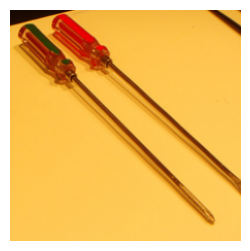

In [8]:
model = load_model(MODEL_NAME)
x, y  = load_image(IMG_IDX)
y_true = y.item()
base_conf = correct_ans_conf(model, x, y)
yhat = model(x).argmax().item()
print(f"true: {class_name(y_true)} ({y_true})   pred: {class_name(yhat)} ({yhat})   P(true) = {base_conf:.4f}")
plt.figure(figsize=(3, 3)); plt.imshow(denorm(x[0])); plt.axis('off');

### Resolve each sweep's parameter (grad ranking at the trained weights)

In [9]:
layers = weighted_layers(model)

for k, s in enumerate(SWEEPS, start=1):
    name, layer = layers[s['li']]
    g = layer_grad(model, layer, x, y)
    _, idxs = g.abs().topk(TOP_N)
    flat_idx = idxs[s['grad_index']].item()
    layer_num = s['li'] % len(layers) + 1          # 1-indexed for the theta superscript (fc of plain8 -> 8)
    coord = tuple(int(c) for c in np.unravel_index(flat_idx, layer.weight.shape))
    s.update(k=k, name=name, layer=layer, flat_idx=flat_idx, coord=coord, layer_num=layer_num,
             w0=layer.weight.view(-1)[flat_idx].item(), grad=g[flat_idx].item(),
             theta_label=theta_latex(coord, layer_num), out_dir=OUT_ROOT / f'p27_sweep_{k}')

print(f"{'k':>2} {'li':>3} {'layer':<16} {'L#':>3} {'grad_idx':>8} {'coord':<22} {'w0':>8} {'dL/dw':>8}  color")
for s in SWEEPS:
    print(f"{s['k']:>2} {s['li']:>3} {s['name']:<16} {s['layer_num']:>3} {s['grad_index']:>8} {str(s['coord']):<22} "
          f"{s['w0']:>8.4f} {s['grad']:>8.4f}  {s['color']}")

 k  li layer             L# grad_idx coord                        w0    dL/dw  color
 1  -1 fc                 8        0 (784, 103)               0.2151  -2.9646  m
 2  -3 layer3.0.conv1     6        0 (63, 10, 0, 0)           0.0124  -0.6833  #eb8423
 3   3 layer2.0.conv1     4        1 (59, 8, 0, 2)           -0.0081  -0.8715  #419c52
 4   2 layer1.0.conv2     3        7 (34, 14, 2, 1)           0.1827   0.5634  #ed5e78
 5   0 conv1              1        0 (33, 0, 6, 1)            0.0995  -0.4665  #d73b2f


### Sanity check: all five curves at the trained weights

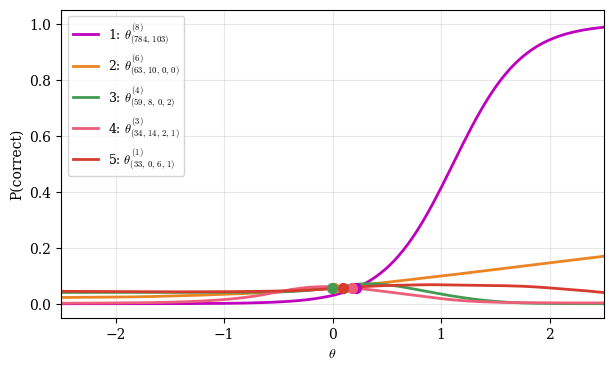

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for s in SWEEPS:
    vals, res, _ = sweep_weight(model, s['layer'], s['flat_idx'], x, y, SPAN, N_POINTS)
    s['base_res'] = res
    ax.plot(vals, res, c=s['color'], linewidth=2, label=f"{s['k']}: {s['theta_label']}")
    ax.scatter(s['w0'], base_conf, c=s['color'], s=50, zorder=10)
ax.set_xlim(-SPAN, SPAN); ax.set_ylim(*CURVE_YLIM); ax.grid(alpha=0.3); ax.legend(fontsize=9)
ax.set_xlabel(r'$\theta$'); ax.set_ylabel('P(correct)');
assert abs(correct_ans_conf(model, x, y) - base_conf) < 1e-6, "weights not restored!"

In [11]:
# rough runtime estimate: each frame of sweep k costs 1 forward + (n_sweeps-1) * N_POINTS forwards for the other curves
t = time.time(); [correct_ans_conf(model, x, y) for _ in range(50)]; fwd = (time.time() - t) / 50
n_fwd = len(SWEEPS_TO_RUN) * N_POINTS * (1 + (len(SWEEPS) - 1) * N_POINTS)
n_png = len(SWEEPS_TO_RUN) * (N_POINTS * (2 + (len(SWEEPS) - 1)) + 2 * N_POINTS + 1)
print(f"{fwd*1e3:.1f} ms / forward  ->  ~{n_fwd*fwd/60:.0f} min of forwards, plus ~{n_png} PNGs (~{n_png*0.25/60:.0f} min at ~0.25 s each)")

0.3 ms / forward  ->  ~2 min of forwards, plus ~5125 PNGs (~21 min at ~0.25 s each)


In [12]:
np.linspace(-SPAN, SPAN, N_POINTS)

array([-2.5       , -2.46062992, -2.42125984, -2.38188976, -2.34251969,
       -2.30314961, -2.26377953, -2.22440945, -2.18503937, -2.14566929,
       -2.10629921, -2.06692913, -2.02755906, -1.98818898, -1.9488189 ,
       -1.90944882, -1.87007874, -1.83070866, -1.79133858, -1.7519685 ,
       -1.71259843, -1.67322835, -1.63385827, -1.59448819, -1.55511811,
       -1.51574803, -1.47637795, -1.43700787, -1.3976378 , -1.35826772,
       -1.31889764, -1.27952756, -1.24015748, -1.2007874 , -1.16141732,
       -1.12204724, -1.08267717, -1.04330709, -1.00393701, -0.96456693,
       -0.92519685, -0.88582677, -0.84645669, -0.80708661, -0.76771654,
       -0.72834646, -0.68897638, -0.6496063 , -0.61023622, -0.57086614,
       -0.53149606, -0.49212598, -0.45275591, -0.41338583, -0.37401575,
       -0.33464567, -0.29527559, -0.25590551, -0.21653543, -0.17716535,
       -0.13779528, -0.0984252 , -0.05905512, -0.01968504,  0.01968504,
        0.05905512,  0.0984252 ,  0.13779528,  0.17716535,  0.21

## Run the sweeps

In [12]:
GC_EVERY = 8   # frames between gc.collect() + RSS readout in the progress bar

def rss_gb():
    try:
        import psutil, os
        return psutil.Process(os.getpid()).memory_info().rss / 1e9
    except ImportError:
        return float('nan')

def run_sweep(s, sweeps):
    others = [o for o in sweeps if o['k'] != s['k']]
    d = s['out_dir']
    dirs = {n: d / n for n in ['cache', 'probs', 'equations', 'curve']}
    for o in others: dirs[o['k']] = d / 'other_curves' / f"param_{o['k']}"
    for p in dirs.values(): p.mkdir(parents=True, exist_ok=True)

    layer, flat_idx, w0, color = s['layer'], s['flat_idx'], s['w0'], s['color']
    vals = np.linspace(-SPAN, SPAN, N_POINTS)
    res = np.empty(N_POINTS)
    other_curves = {o['k']: np.empty((N_POINTS, N_POINTS)) for o in others}

    # frame 0 of the equations = pre-sweep (trained) value
    render_equation(s['theta_label'], w0, P_LABEL, base_conf, color, dirs['equations'] / 'frame_0000.png')

    with torch.no_grad():
        w = layer.weight.view(-1)
        pbar = tqdm(vals, desc=f"sweep {s['k']} {s['theta_label']}")
        for i, v in enumerate(pbar):
            w[flat_idx] = v
            with ActivationCache(model) as cache:
                model(x)
            probs = F.softmax(cache['fc'].ravel(), dim=0).numpy()
            res[i] = probs[y_true]

            np.save(dirs['cache'] / f'{i:03d}', {k_: v_.numpy() for k_, v_ in cache.items()})
            del cache
            render_probs(probs, y_true, dirs['probs'] / f'{i:03d}.png')
            render_equation(s['theta_label'], v, P_LABEL, res[i], color, dirs['equations'] / f'frame_{i+1:04d}.png')

            # the other four curves, with theta_k held at v; dot at each one's own trained value
            for o in others:
                _, r_o, _ = sweep_weight(model, o['layer'], o['flat_idx'], x, y, SPAN, N_POINTS)
                other_curves[o['k']][i] = r_o
                render_curve(vals, r_o, o['color'], dirs[o['k']] / f'frame_{i:03d}.png', dot=(o['w0'], res[i]))
            if i % GC_EVERY == 0:
                gc.collect(); pbar.set_postfix(rss=f'{rss_gb():.2f} GB')
        w[flat_idx] = w0
    assert abs(correct_ans_conf(model, x, y) - base_conf) < 1e-6, "weights not restored!"

    # own curve: draw-in, then a dot moving along it
    for i in tqdm(range(N_POINTS), desc='curve draw-in', leave=False):
        render_curve(vals, res, color, dirs['curve'] / f"p27_sweep_{s['k']}_curve_{i:03d}.png", upto=i)
    for i in tqdm(range(N_POINTS), desc='curve dot', leave=False):
        render_curve(vals, res, color, dirs['curve'] / f"p27_sweep_{s['k']}_curve_{N_POINTS+i:03d}.png", dot=(vals[i], res[i]))

    np.save(d / 'curve.npy', np.stack([vals, res]))
    for o in others: np.save(dirs[o['k']] / 'curves.npy', other_curves[o['k']])
    json.dump({
        'sweep': s['k'], 'model': MODEL_NAME, 'img_idx': IMG_IDX, 'class_idx': y_true, 'class': class_name(y_true),
        'li': s['li'], 'layer_name': s['name'], 'layer_num': s['layer_num'], 'grad_index': s['grad_index'],
        'flat_idx': s['flat_idx'], 'coord': list(s['coord']), 'w0': w0, 'grad': s['grad'], 'color': color,
        'theta_label': s['theta_label'], 'span': SPAN, 'n_points': N_POINTS, 'base_conf': base_conf,
        'other_params': {o['k']: {'coord': list(o['coord']), 'layer_num': o['layer_num'], 'w0': o['w0'], 'color': o['color']} for o in others},
    }, open(d / 'summary.json', 'w'), indent=2)
    return vals, res, other_curves

In [13]:
results = {}
for s in SWEEPS:
    if s['k'] in SWEEPS_TO_RUN:
        results[s['k']] = run_sweep(s, SWEEPS)

sweep 1 $\theta_{(784,\,103)}^{(8)}$: 100%|█| 128/128 [01:07<00:00,  1.88it/s, r
sweep 2 $\theta_{(63,\,10,\,0,\,0)}^{(6)}$: 100%|█| 128/128 [01:07<00:00,  1.89i
sweep 3 $\theta_{(59,\,8,\,0,\,2)}^{(4)}$: 100%|█| 128/128 [01:08<00:00,  1.88it
sweep 4 $\theta_{(34,\,14,\,2,\,1)}^{(3)}$: 100%|█| 128/128 [01:09<00:00,  1.85i
sweep 5 $\theta_{(33,\,0,\,6,\,1)}^{(1)}$: 100%|█| 128/128 [01:07<00:00,  1.90it
                                                                                

### Preview: how much do the other curves actually move during each sweep?

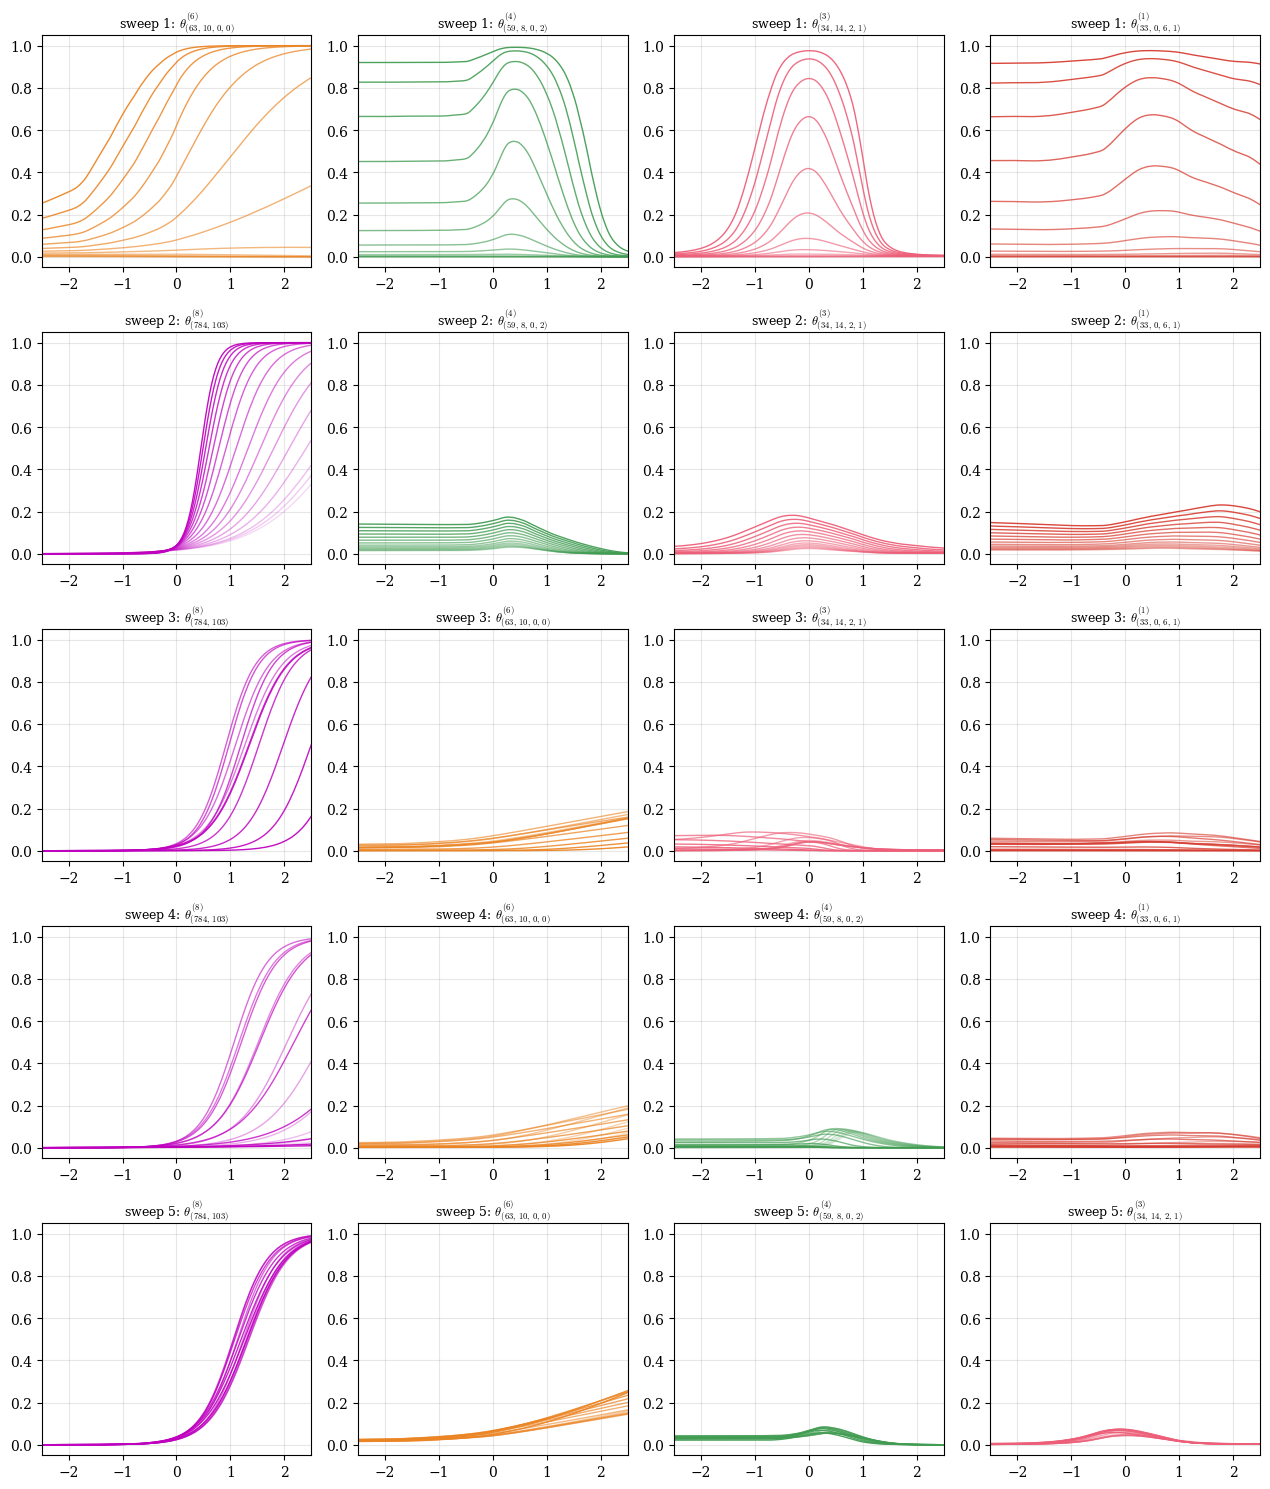

In [14]:
fig, axes = plt.subplots(len(results), len(SWEEPS) - 1, figsize=(3.2 * (len(SWEEPS) - 1), 3 * len(results)), squeeze=False)
for row, (k, (vals, res, other_curves)) in enumerate(results.items()):
    for col, (j, curves) in enumerate(other_curves.items()):
        ax = axes[row, col]
        o = SWEEPS[j - 1]
        for i in range(0, N_POINTS, max(1, N_POINTS // 16)):
            ax.plot(vals, curves[i], c=o['color'], alpha=0.15 + 0.85 * i / N_POINTS, linewidth=1)
        ax.set_xlim(-SPAN, SPAN); ax.set_ylim(*CURVE_YLIM); ax.grid(alpha=0.3)
        ax.set_title(f"sweep {k}: {o['theta_label']}", fontsize=9)
plt.tight_layout()

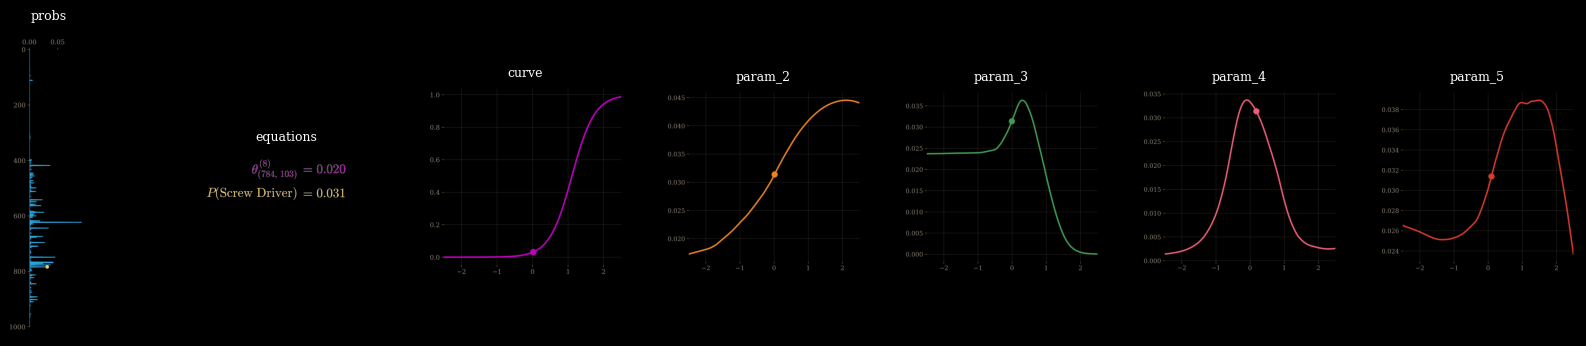

In [15]:
# eyeball a few exported frames from one sweep
from PIL import Image
k = SWEEPS_TO_RUN[0]; d = SWEEPS[k-1]['out_dir']; i = N_POINTS // 2
paths = [d / 'probs' / f'{i:03d}.png', d / 'equations' / f'frame_{i+1:04d}.png',
         d / 'curve' / f'p27_sweep_{k}_curve_{N_POINTS+i:03d}.png'] + \
        [d / 'other_curves' / f'param_{o["k"]}' / f'frame_{i:03d}.png' for o in SWEEPS if o['k'] != k]
fig, axes = plt.subplots(1, len(paths), figsize=(3 * len(paths), 4), facecolor='k')
for ax, p in zip(axes, paths):
    ax.imshow(Image.open(p)); ax.axis('off'); ax.set_title(p.parent.name, color='w', fontsize=9)

## Load up some exports and quick gut check

frames [0, 32, 64, 96, 127]
fc entries that change: [784]   max |Δ| = 15.7106
fc[784] per frame: [-0.9043  3.0543  7.0129 10.9714 14.8063]
fc range per frame: [(np.float32(-7.261), np.float32(8.092)), (np.float32(-7.261), np.float32(8.092)), (np.float32(-7.261), np.float32(8.092)), (np.float32(-7.261), np.float32(10.971)), (np.float32(-7.261), np.float32(14.806))]
  fc                     changes, max |Δ| = 15.7106


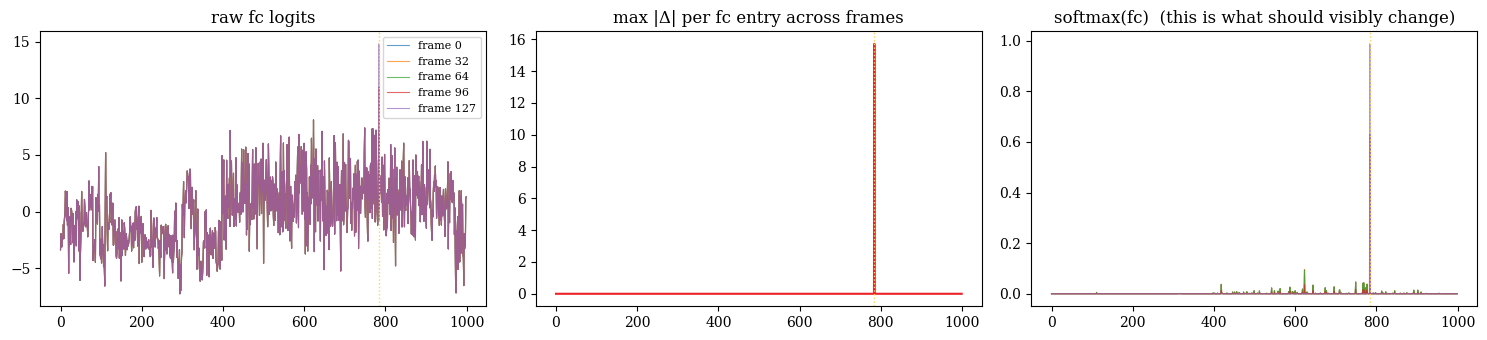

In [12]:
# --- diagnostic: is act['fc'] changing across the sweep_1 cache files? ---
d = OUT_ROOT / 'p27_sweep_1' / 'cache'
files = sorted(d.glob('*.npy'))
picks = [0, len(files)//4, len(files)//2, 3*len(files)//4, len(files)-1]
acts = [np.load(files[i], allow_pickle=True).item() for i in picks]
fc = np.stack([a['fc'].ravel() for a in acts])                 # (5, 1000)

# which entries move at all?
delta = np.abs(fc - fc[0]).max(axis=0)
moving = np.flatnonzero(delta > 1e-6)
print('frames', picks)
print(f'fc entries that change: {moving}   max |Δ| = {delta.max():.4f}')
print('fc[784] per frame:', fc[:, 784].round(4))
print('fc range per frame:', [(f.min().round(3), f.max().round(3)) for f in fc])

# do any earlier layers change?  (they shouldn't for an fc sweep)
for name in acts[0]:
    m = max(np.abs(a[name] - acts[0][name]).max() for a in acts[1:])
    if m > 1e-6: print(f'  {name:<22} changes, max |Δ| = {m:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for f, i in zip(fc, picks): axes[0].plot(f, lw=0.8, alpha=0.7, label=f'frame {i}')
axes[0].set_title('raw fc logits'); axes[0].legend(fontsize=8)
axes[1].plot(delta, c=RED); axes[1].set_title('max |Δ| per fc entry across frames')
sm = np.exp(fc - fc.max(1, keepdims=True)); sm /= sm.sum(1, keepdims=True)
for s, i in zip(sm, picks): axes[2].plot(s, lw=0.8, alpha=0.7)
axes[2].set_title('softmax(fc)  (this is what should visibly change)')
for ax in axes: ax.axvline(y_true, c=YELLOW, ls=':', lw=1)
plt.tight_layout()

In [16]:
fc.shape

(5, 1000)

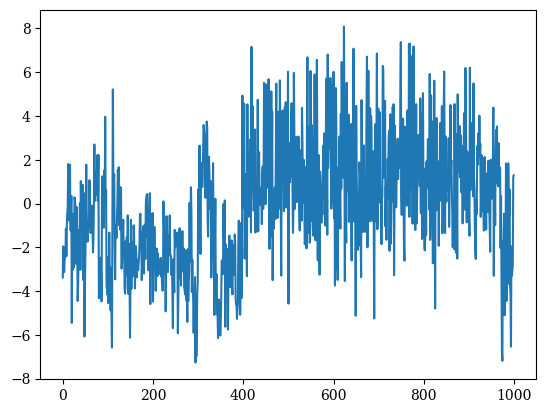

In [17]:
plt.plot(fc[0])

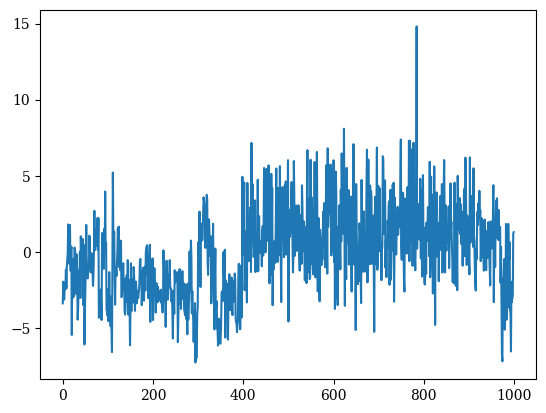

In [19]:
plt.plot(fc[4])